## Project 2 (Level-2) : Wine Quality Prediction
Author : Neha Tiwari

**1. Import Liabraries**

In [5]:
# Data Analysis
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Preprocessing and Evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# SMOTE for balancing classes
from imblearn.over_sampling import SMOTE


**2. Load Dataset**

In [12]:
# Load the dataset (Update with your actual path or upload via GUI)
df = pd.read_csv("WineQT.csv")

# Drop the 'Id' column as it's not useful for prediction
df.drop('Id', axis=1, inplace=True)

# Preview the dataset
print(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

**3. Clean & Simplify Data**

In [13]:
# Check if 'quality' is already numeric
df['quality'] = pd.to_numeric(df['quality'], errors='coerce')

# Define quality labels
def simplify_quality(q):
    if q <= 5:
        return 'Low'
    elif q == 6:
        return 'Medium'
    else:
        return 'High'

# Apply transformation
df['quality'] = df['quality'].apply(simplify_quality)

# Check new distribution
print("✅ Class distribution:\n", df['quality'].value_counts())



✅ Class distribution:
 quality
Low       522
Medium    462
High      159
Name: count, dtype: int64


**4. Visualize Class Distribution**

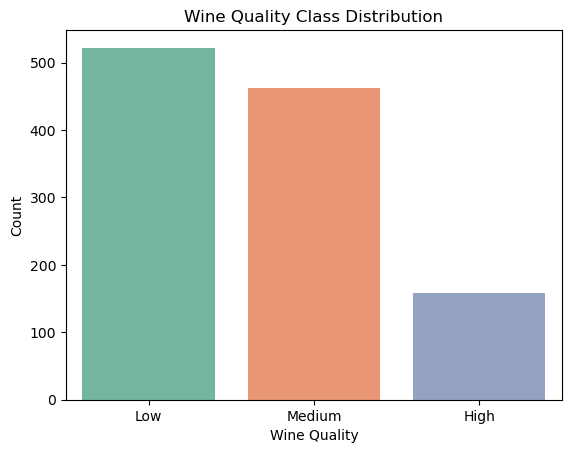

In [15]:
sns.countplot(data=df, x='quality', hue='quality', palette='Set2', legend=False)
plt.title("Wine Quality Class Distribution")
plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.show()


**5. Train-Test Split**

In [16]:
X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("✅ y_test class distribution:\n", y_test.value_counts())


✅ y_test class distribution:
 quality
Low       105
Medium     92
High       32
Name: count, dtype: int64


**6. Apply SMOTE and Scaling**

In [18]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


**7. Random Forest Classifier**

In [19]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_resampled)
y_pred_rf = rf.predict(X_test_scaled)

print("🌲 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))


🌲 Random Forest Accuracy: 0.6681222707423581
              precision    recall  f1-score   support

        High       0.51      0.72      0.60        32
         Low       0.79      0.74      0.76       105
      Medium       0.61      0.57      0.59        92

    accuracy                           0.67       229
   macro avg       0.64      0.68      0.65       229
weighted avg       0.68      0.67      0.67       229



**8. SGD Classifier**

In [20]:
sgd = SGDClassifier(max_iter=1000, tol=1e-3, class_weight='balanced', random_state=42)
sgd.fit(X_train_scaled, y_train_resampled)
y_pred_sgd = sgd.predict(X_test_scaled)

print("📉 SGD Accuracy:", accuracy_score(y_test, y_pred_sgd))
print(classification_report(y_test, y_pred_sgd, zero_division=0))


📉 SGD Accuracy: 0.5414847161572053
              precision    recall  f1-score   support

        High       0.37      0.75      0.49        32
         Low       0.71      0.64      0.67       105
      Medium       0.47      0.36      0.41        92

    accuracy                           0.54       229
   macro avg       0.52      0.58      0.53       229
weighted avg       0.57      0.54      0.54       229



**9. SVC Classifier**

In [21]:
svc = SVC(kernel='linear', class_weight='balanced', random_state=42)
svc.fit(X_train_scaled, y_train_resampled)
y_pred_svc = svc.predict(X_test_scaled)

print("🔷 SVC Accuracy:", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc, zero_division=0))


🔷 SVC Accuracy: 0.5807860262008734
              precision    recall  f1-score   support

        High       0.43      0.78      0.56        32
         Low       0.72      0.70      0.71       105
      Medium       0.50      0.38      0.43        92

    accuracy                           0.58       229
   macro avg       0.55      0.62      0.57       229
weighted avg       0.59      0.58      0.58       229



**10. Compare Predictions**

In [22]:
print("✅ Actual class distribution:\n", y_test.value_counts())
print("\n📘 RF Predicted:\n", pd.Series(y_pred_rf).value_counts())
print("\n📙 SGD Predicted:\n", pd.Series(y_pred_sgd).value_counts())
print("\n📗 SVC Predicted:\n", pd.Series(y_pred_svc).value_counts())


✅ Actual class distribution:
 quality
Low       105
Medium     92
High       32
Name: count, dtype: int64

📘 RF Predicted:
 Low       99
Medium    85
High      45
Name: count, dtype: int64

📙 SGD Predicted:
 Low       94
Medium    70
High      65
Name: count, dtype: int64

📗 SVC Predicted:
 Low       101
Medium     70
High       58
Name: count, dtype: int64


## 📊 Project Summary: Wine Quality Prediction

This project focuses on predicting the **quality of red wine** based on its **chemical properties** using three classification models:  
- **Random Forest Classifier**  
- **Stochastic Gradient Descent (SGD)**  
- **Support Vector Classifier (SVC)**

---

### 🧪 Dataset Overview
- **Total Samples**: 1,143
- **Features**: 11 (e.g., alcohol, pH, sulphates, density)
- **Target Variable**: Wine Quality (categorized as `Low`, `Medium`, `High`)

---

### ⚙️ Models & Accuracy

| Model      | Accuracy | Best For              |
|------------|----------|------------------------|
| Random Forest 🌲 | **66.8%**  | Overall balance ✅ |
| SGD 📉        | 54.1%    | High recall on `High` |
| SVC 🔷        | 58.0%    | Moderate performance  |

---

### ✅ Final Verdict
- **Random Forest** provided the best overall results in accuracy and balanced class prediction.
- **SVC and SGD** showed bias toward `High` quality class and underperformed on `Medium`.

---

### 📌 Tools Used
- Python, Pandas, NumPy, Scikit-learn  
- Seaborn & Matplotlib for visualization  
- SMOTE for balancing class distribution  
- StandardScaler for feature scaling

---

